# Post-Surgery Recovery — EDA & LSTM Training

This notebook performs comprehensive Exploratory Data Analysis on the synthetic post-surgery recovery dataset and trains a hybrid LSTM model for:
1. **Recovery score forecasting** (3-day ahead regression)
2. **Complication risk prediction** (binary classification)

**Dataset:** 1,000 patients × 30 days = 30,000 records with 7 daily vitals + 7 static features

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

In [2]:
# Load the synthetic recovery dataset
DATA_PATH = os.path.join("..", "data", "synthetic_recovery_data.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
print("First 5 rows:")
display(df.head())
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (30000, 19)
Columns: ['patient_id', 'age', 'gender', 'bmi', 'diabetes', 'hypertension', 'surgery_type', 'smoking', 'outcome', 'day', 'pain_level', 'temperature', 'heart_rate', 'bp_systolic', 'mobility_score', 'wound_status', 'sleep_hours', 'recovery_score', 'complication_flag']

First 5 rows:


,patient_id,age,gender,bmi,diabetes,hypertension,surgery_type,smoking,outcome,day,pain_level,temperature,heart_rate,bp_systolic,mobility_score,wound_status,sleep_hours,recovery_score,complication_flag
0,1,63,1,21.4,0,0,neurological,0,normal,1,7.9,37.7,90,131,2.3,0.96,4.9,27.3,0
1,1,63,1,21.4,0,0,neurological,0,normal,2,6.3,37.8,88,129,1.8,0.92,5.1,25.3,0
2,1,63,1,21.4,0,0,neurological,0,normal,3,7.5,37.8,91,128,2.8,0.88,4.5,30.0,0
3,1,63,1,21.4,0,0,neurological,0,normal,4,7.0,37.7,86,125,3.5,0.84,5.5,29.6,0
4,1,63,1,21.4,0,0,neurological,0,normal,5,7.0,37.5,86,126,4.1,0.80,5.0,29.2,0



Missing Values:
patient_id           0
age                  0
gender               0
bmi                  0
diabetes             0
hypertension         0
surgery_type         0
smoking              0
outcome              0
day                  0
pain_level           0
temperature          0
heart_rate           0
bp_systolic          0
mobility_score       0
wound_status         0
sleep_hours          0
recovery_score       0
complication_flag    0
dtype: int64

Data Types:
patient_id             int64
age                    int64
gender                 int64
bmi                  float64
diabetes               int64
hypertension           int64
surgery_type             str
smoking                int64
outcome                  str
day                    int64
pain_level           float64
temperature          float64
heart_rate             int64
bp_systolic            int64
mobility_score       float64
wound_status         float64
sleep_hours          float64
recovery_score       float6

,patient_id,age,gender,bmi,diabetes,hypertension,smoking,day,pain_level,temperature,heart_rate,bp_systolic,mobility_score,wound_status,sleep_hours,recovery_score,complication_flag
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.0000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,500.500000,51.875000,0.501000,26.931700,0.25000,0.2940,0.29000,15.500000,5.400357,37.683777,89.007700,131.081633,4.591553,0.542957,5.738000,46.769003,0.075500
std,288.679802,15.865679,0.500007,5.033083,0.43302,0.4556,0.45377,8.655586,2.169682,0.509432,10.939563,10.981338,2.733759,0.315532,1.734318,26.969272,0.264201
min,1.000000,25.000000,0.000000,16.000000,0.00000,0.0000,0.00000,1.000000,1.000000,37.000000,66.000000,103.000000,0.000000,0.000000,0.700000,0.000000,0.000000
25%,250.750000,38.000000,0.000000,23.700000,0.00000,0.0000,0.00000,8.000000,3.900000,37.300000,81.000000,124.000000,2.600000,0.320000,4.500000,26.975000,0.000000
50%,500.500000,52.000000,1.000000,26.800000,0.00000,0.0000,0.00000,15.500000,5.600000,37.600000,87.000000,129.000000,4.400000,0.600000,5.700000,44.900000,0.000000
75%,750.250000,66.000000,1.000000,30.400000,0.25000,1.0000,1.00000,23.000000,7.000000,37.900000,93.000000,136.000000,6.500000,0.810000,7.000000,66.100000,0.000000
max,1000.000000,79.000000,1.000000,43.600000,1.00000,1.0000,1.00000,30.000000,10.000000,39.800000,132.000000,176.000000,10.000000,1.000000,9.000000,100.000000,1.000000


## 2. Dataset Overview

In [3]:
# Dataset overview
patients = df.groupby("patient_id").first().reset_index()

print(f"Total Records: {len(df):,}")
print(f"Unique Patients: {df['patient_id'].nunique()}")
print(f"Days per Patient: {df['day'].nunique()}")

print(f"\n--- Outcome Distribution ---")
outcome_counts = patients['outcome'].value_counts()
for outcome, count in outcome_counts.items():
    print(f"  {outcome.capitalize():15s}: {count:5d} ({count/len(patients)*100:.1f}%)")

print(f"\n--- Surgery Type Distribution ---")
surgery_counts = patients['surgery_type'].value_counts()
for stype, count in surgery_counts.items():
    print(f"  {stype.capitalize():15s}: {count:5d} ({count/len(patients)*100:.1f}%)")

print(f"\n--- Comorbidity Prevalence ---")
print(f"  Diabetes:      {patients['diabetes'].mean()*100:.1f}%")
print(f"  Hypertension:  {patients['hypertension'].mean()*100:.1f}%")
print(f"  Smoking:       {patients['smoking'].mean()*100:.1f}%")
print(f"\n--- Age & BMI ---")
print(f"  Age Range: {patients['age'].min()} - {patients['age'].max()} (Mean: {patients['age'].mean():.1f})")
print(f"  BMI Range: {patients['bmi'].min()} - {patients['bmi'].max()} (Mean: {patients['bmi'].mean():.1f})")

Total Records: 30,000
Unique Patients: 1000
Days per Patient: 30

--- Outcome Distribution ---
  Normal         :   544 (54.4%)
  Slow           :   305 (30.5%)
  Complication   :   151 (15.1%)

--- Surgery Type Distribution ---
  Abdominal      :   261 (26.1%)
  Orthopedic     :   255 (25.5%)
  Cardiac        :   253 (25.3%)
  Neurological   :   231 (23.1%)

--- Comorbidity Prevalence ---
  Diabetes:      25.0%
  Hypertension:  29.4%
  Smoking:       29.0%

--- Age & BMI ---
  Age Range: 25 - 79 (Mean: 51.9)
  BMI Range: 16.0 - 43.6 (Mean: 26.9)


## 3. Outcome Distribution

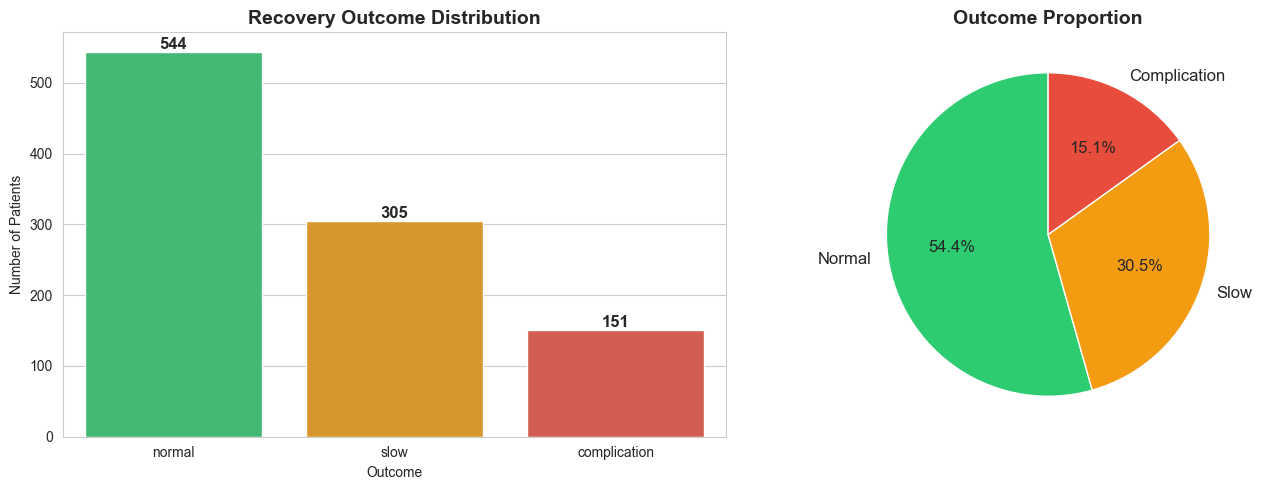

In [4]:
# Outcome distribution — Count plot + Pie chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
outcome_order = ['normal', 'slow', 'complication']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=patients, x='outcome', order=outcome_order, palette=colors, ax=axes[0])
axes[0].set_title("Recovery Outcome Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Number of Patients")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
outcome_counts = patients['outcome'].value_counts().reindex(outcome_order)
axes[1].pie(outcome_counts, labels=[o.capitalize() for o in outcome_order], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Outcome Proportion", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Patient Demographics Analysis

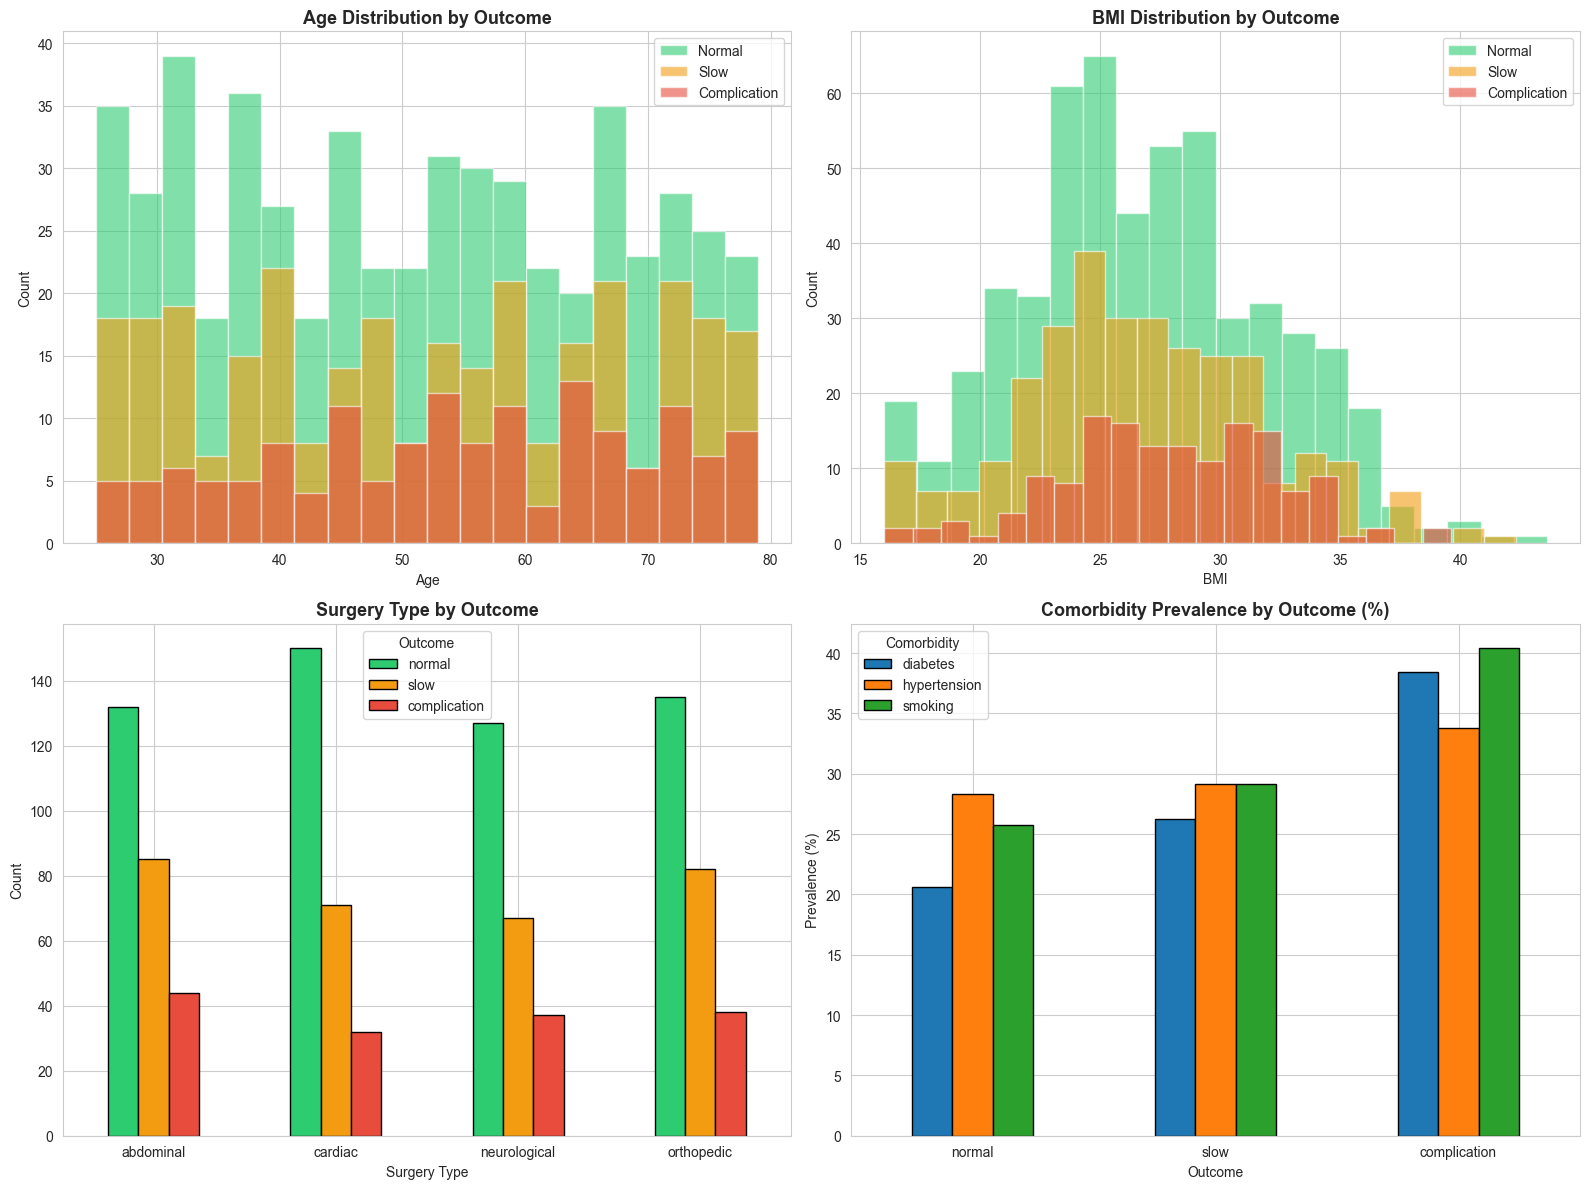

In [5]:
# Demographics analysis — 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
outcome_order = ['normal', 'slow', 'complication']

# 1. Age distribution by outcome
for i, outcome in enumerate(outcome_order):
    subset = patients[patients['outcome'] == outcome]
    axes[0, 0].hist(subset['age'], bins=20, alpha=0.6, label=outcome.capitalize(), color=colors[i])
axes[0, 0].set_title("Age Distribution by Outcome", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# 2. BMI distribution by outcome
for i, outcome in enumerate(outcome_order):
    subset = patients[patients['outcome'] == outcome]
    axes[0, 1].hist(subset['bmi'], bins=20, alpha=0.6, label=outcome.capitalize(), color=colors[i])
axes[0, 1].set_title("BMI Distribution by Outcome", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# 3. Surgery type by outcome
surgery_outcome = patients.groupby(['surgery_type', 'outcome']).size().unstack(fill_value=0)
surgery_outcome = surgery_outcome[outcome_order]
surgery_outcome.plot(kind='bar', ax=axes[1, 0], color=colors, edgecolor='black')
axes[1, 0].set_title("Surgery Type by Outcome", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Surgery Type")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(title="Outcome")
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Comorbidity prevalence by outcome
comorbidities = ['diabetes', 'hypertension', 'smoking']
comorb_data = patients.groupby('outcome')[comorbidities].mean().reindex(outcome_order) * 100
comorb_data.plot(kind='bar', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title("Comorbidity Prevalence by Outcome (%)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Outcome")
axes[1, 1].set_ylabel("Prevalence (%)")
axes[1, 1].legend(title="Comorbidity")
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Recovery Trajectory Plots
Mean recovery score over 30 days for each outcome group (Normal / Slow / Complication) with standard deviation shading.

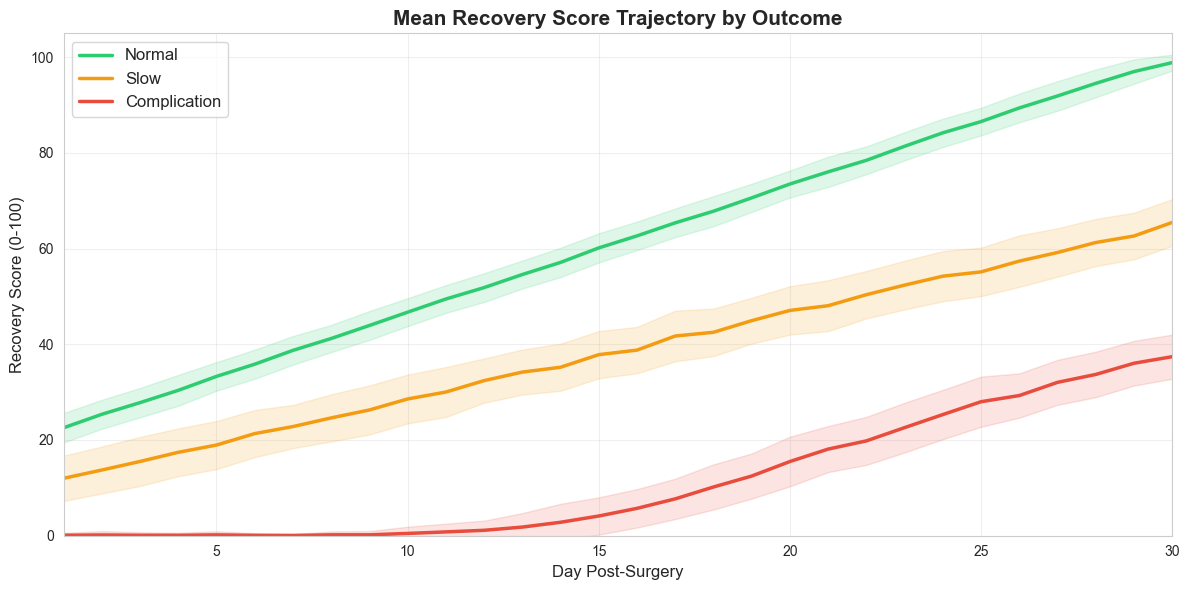

In [6]:
# Recovery score trajectory by outcome
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'normal': '#2ecc71', 'slow': '#f39c12', 'complication': '#e74c3c'}

for outcome in ['normal', 'slow', 'complication']:
    subset = df[df['outcome'] == outcome]
    daily_mean = subset.groupby('day')['recovery_score'].mean()
    daily_std = subset.groupby('day')['recovery_score'].std()
    
    ax.plot(daily_mean.index, daily_mean.values, label=outcome.capitalize(),
            color=colors_map[outcome], linewidth=2.5)
    ax.fill_between(daily_mean.index, daily_mean - daily_std, daily_mean + daily_std,
                    alpha=0.15, color=colors_map[outcome])

ax.set_title("Mean Recovery Score Trajectory by Outcome", fontsize=15, fontweight='bold')
ax.set_xlabel("Day Post-Surgery", fontsize=12)
ax.set_ylabel("Recovery Score (0-100)", fontsize=12)
ax.legend(fontsize=12)
ax.set_xlim(1, 30)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Vital Signs Trajectories by Outcome

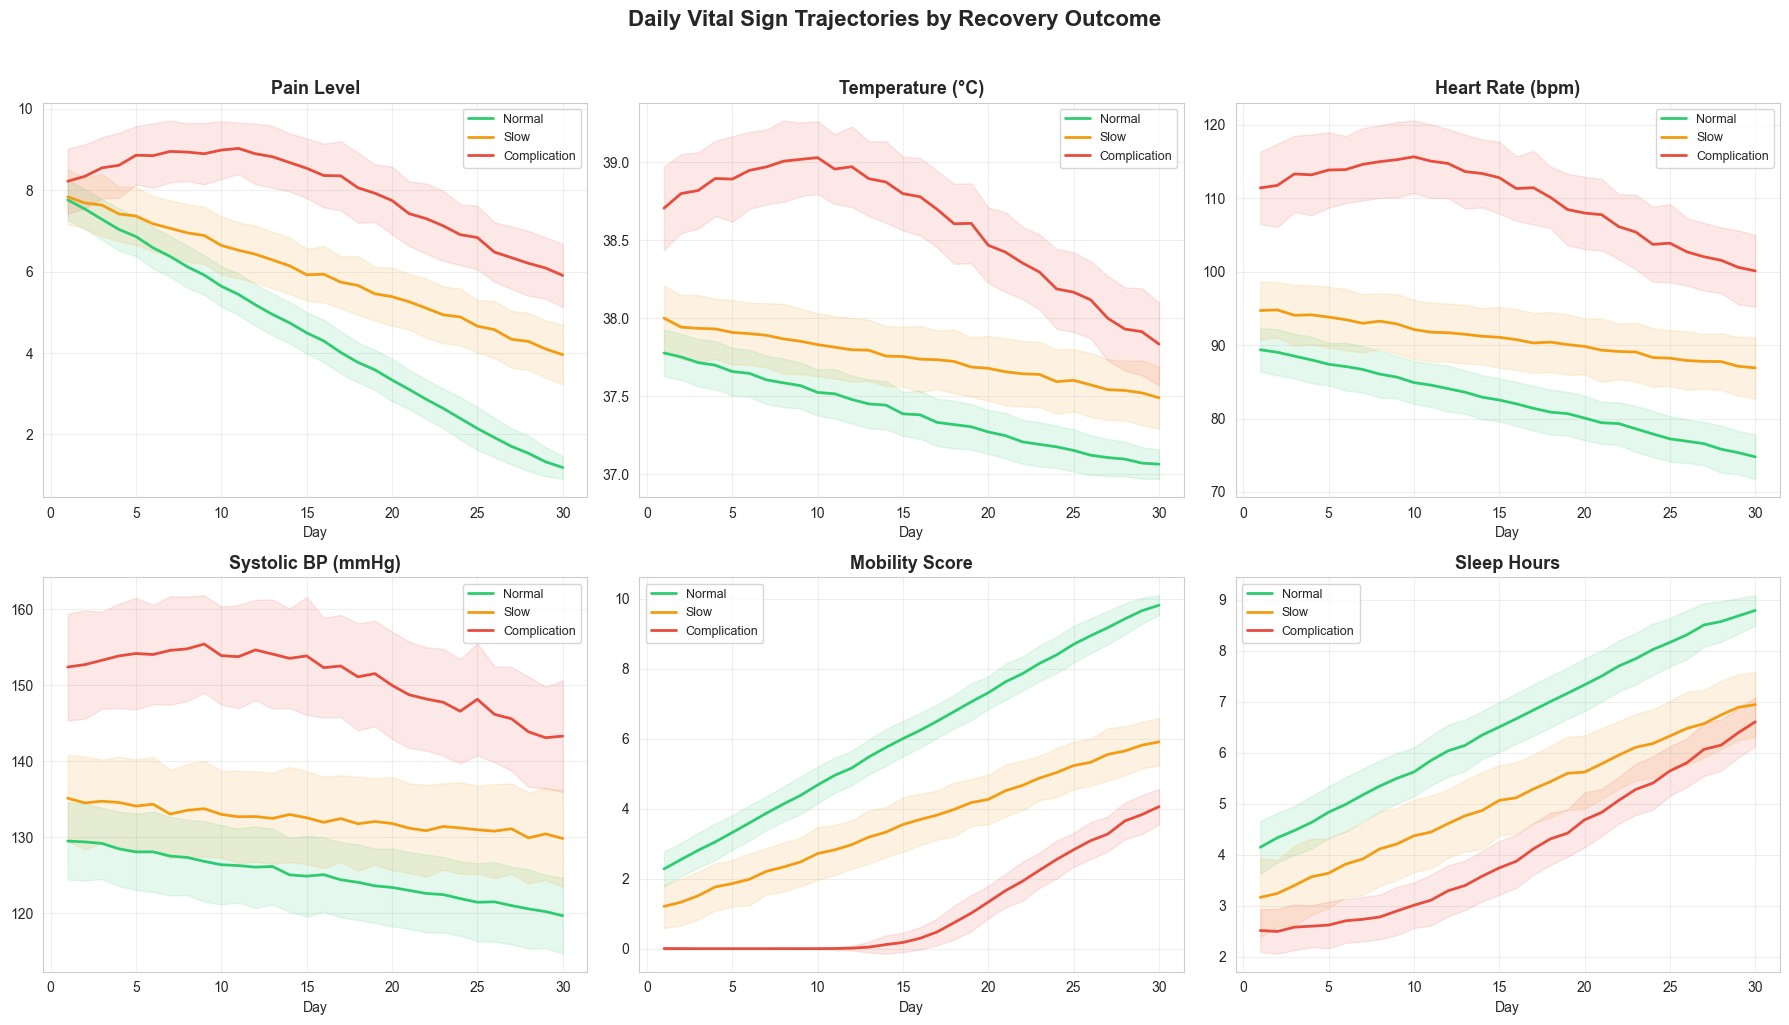

In [7]:
# Vital signs trajectories — 2x3 grid
vitals = ['pain_level', 'temperature', 'heart_rate', 'bp_systolic', 'mobility_score', 'sleep_hours']
titles = ['Pain Level', 'Temperature (°C)', 'Heart Rate (bpm)', 'Systolic BP (mmHg)', 'Mobility Score', 'Sleep Hours']
colors_map = {'normal': '#2ecc71', 'slow': '#f39c12', 'complication': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (vital, title) in enumerate(zip(vitals, titles)):
    ax = axes[idx]
    for outcome in ['normal', 'slow', 'complication']:
        subset = df[df['outcome'] == outcome]
        daily_mean = subset.groupby('day')[vital].mean()
        daily_std = subset.groupby('day')[vital].std()
        
        ax.plot(daily_mean.index, daily_mean.values, label=outcome.capitalize(),
                color=colors_map[outcome], linewidth=2)
        ax.fill_between(daily_mean.index, daily_mean - daily_std, daily_mean + daily_std,
                        alpha=0.12, color=colors_map[outcome])
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Day")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Daily Vital Sign Trajectories by Recovery Outcome", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Complication Patients — Vital Sign Spikes (Days 5-15)
Complication patients show characteristic spikes in temperature, heart rate, pain, and blood pressure around days 5-15 (the danger window).

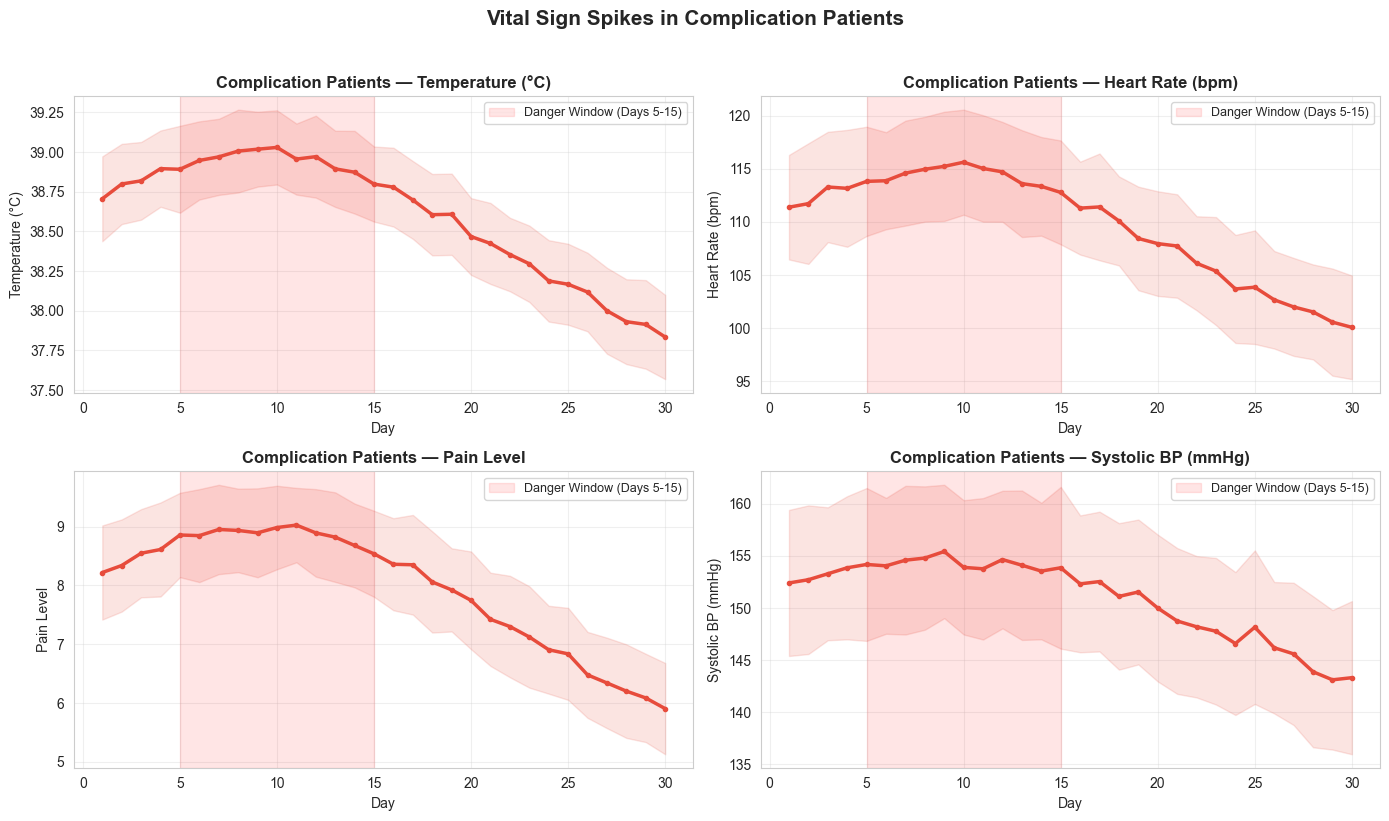

In [8]:
# Complication vital sign spikes with danger window
comp_df = df[df['outcome'] == 'complication']
spike_vitals = ['temperature', 'heart_rate', 'pain_level', 'bp_systolic']
spike_titles = ['Temperature (°C)', 'Heart Rate (bpm)', 'Pain Level', 'Systolic BP (mmHg)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (vital, title) in enumerate(zip(spike_vitals, spike_titles)):
    ax = axes[idx]
    daily_mean = comp_df.groupby('day')[vital].mean()
    daily_std = comp_df.groupby('day')[vital].std()
    
    ax.plot(daily_mean.index, daily_mean.values, color='#e74c3c', linewidth=2.5, marker='o', markersize=3)
    ax.fill_between(daily_mean.index, daily_mean - daily_std, daily_mean + daily_std,
                    alpha=0.15, color='#e74c3c')
    
    # Danger window shading
    ax.axvspan(5, 15, alpha=0.1, color='red', label='Danger Window (Days 5-15)')
    ax.set_title(f"Complication Patients — {title}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Day")
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Vital Sign Spikes in Complication Patients", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Wound Status & Sleep Analysis

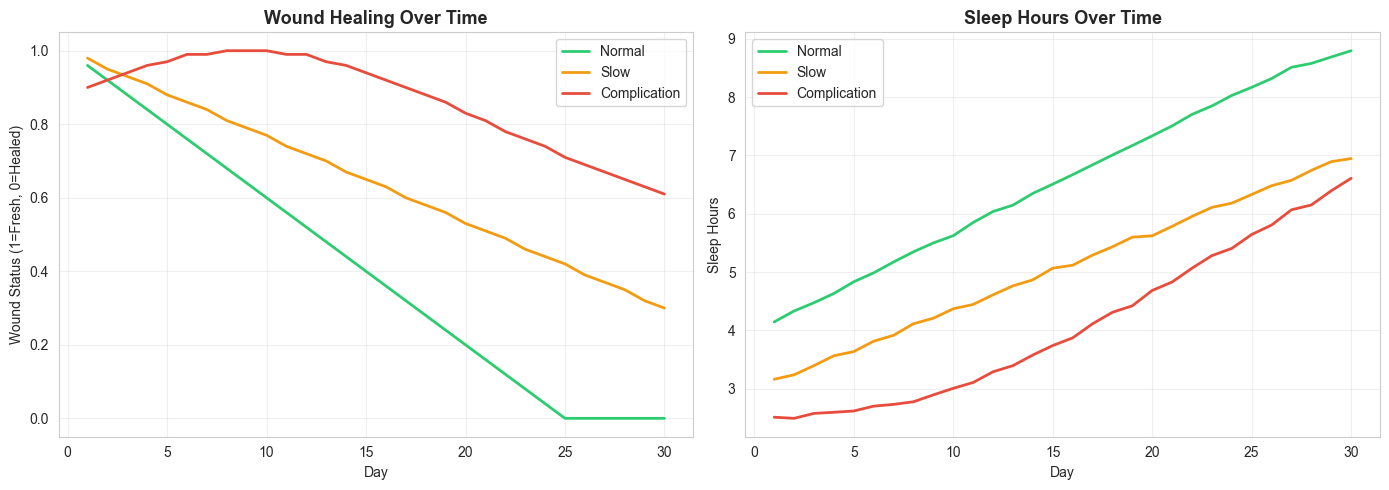

In [9]:
# Wound status & sleep hours by outcome
colors_map = {'normal': '#2ecc71', 'slow': '#f39c12', 'complication': '#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for outcome in ['normal', 'slow', 'complication']:
    subset = df[df['outcome'] == outcome]
    # Wound status
    daily_mean = subset.groupby('day')['wound_status'].mean()
    axes[0].plot(daily_mean.index, daily_mean.values, label=outcome.capitalize(),
                 color=colors_map[outcome], linewidth=2)
    # Sleep hours
    daily_mean = subset.groupby('day')['sleep_hours'].mean()
    axes[1].plot(daily_mean.index, daily_mean.values, label=outcome.capitalize(),
                 color=colors_map[outcome], linewidth=2)

axes[0].set_title("Wound Healing Over Time", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Wound Status (1=Fresh, 0=Healed)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Sleep Hours Over Time", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Sleep Hours")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Risk Score Distribution by Surgery Type

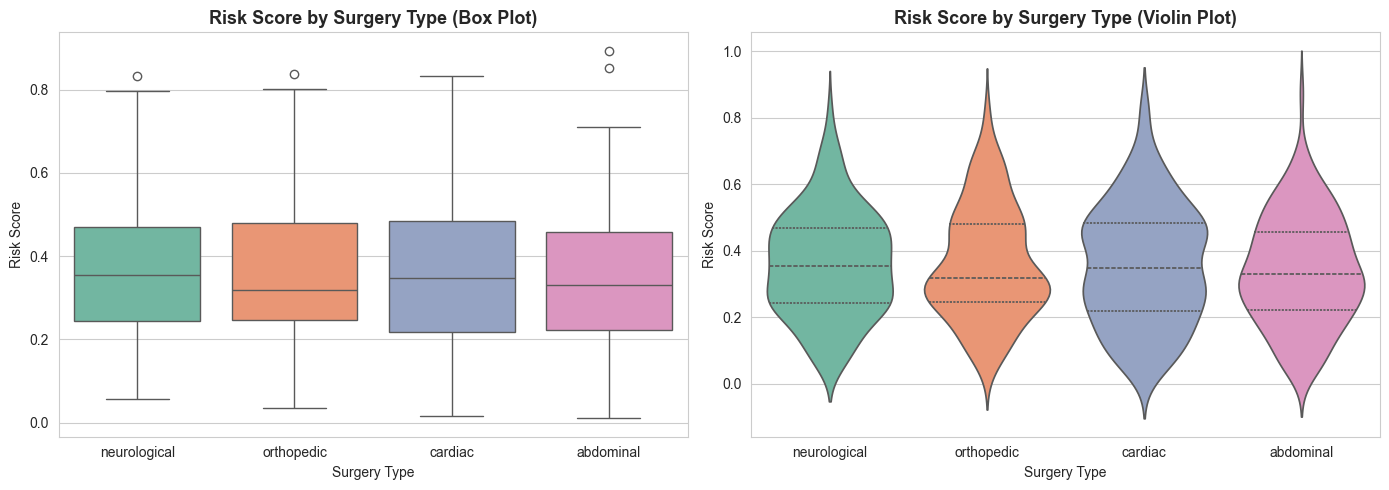

In [10]:
# Calculate risk score per patient
patients['risk_score'] = (
    (patients['age'] - 25) / 55 * 0.3 +
    (patients['bmi'] - 16) / 29 * 0.15 +
    patients['diabetes'] * 0.2 +
    patients['hypertension'] * 0.15 +
    patients['smoking'] * 0.2
).clip(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=patients, x='surgery_type', y='risk_score', ax=axes[0], palette='Set2')
axes[0].set_title("Risk Score by Surgery Type (Box Plot)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Surgery Type")
axes[0].set_ylabel("Risk Score")

# Violin plot
sns.violinplot(data=patients, x='surgery_type', y='risk_score', ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title("Risk Score by Surgery Type (Violin Plot)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Surgery Type")
axes[1].set_ylabel("Risk Score")

plt.tight_layout()
plt.show()

## 10. Correlation Heatmap

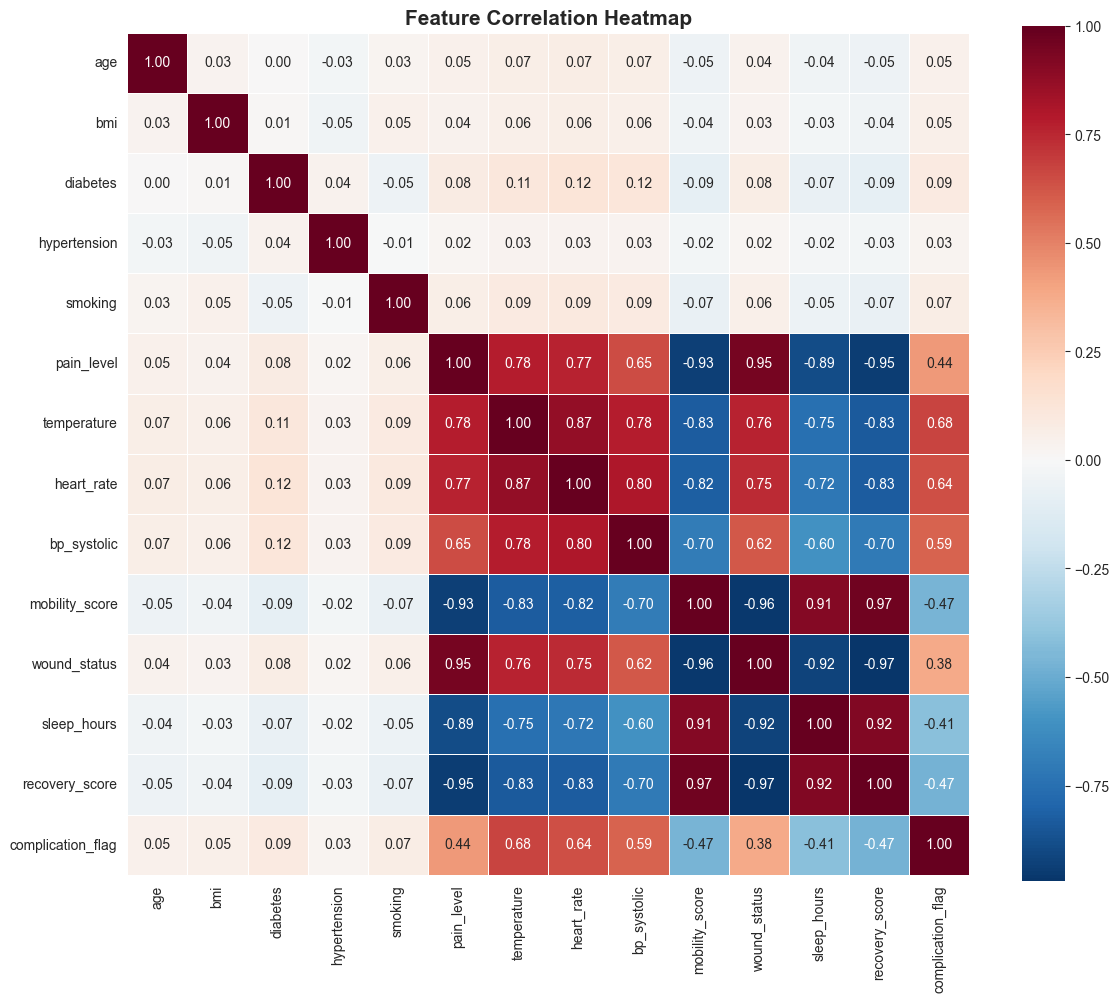

In [11]:
# Correlation heatmap
corr_cols = ['age', 'bmi', 'diabetes', 'hypertension', 'smoking',
             'pain_level', 'temperature', 'heart_rate', 'bp_systolic',
             'mobility_score', 'wound_status', 'sleep_hours',
             'recovery_score', 'complication_flag']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Complication Flag Analysis

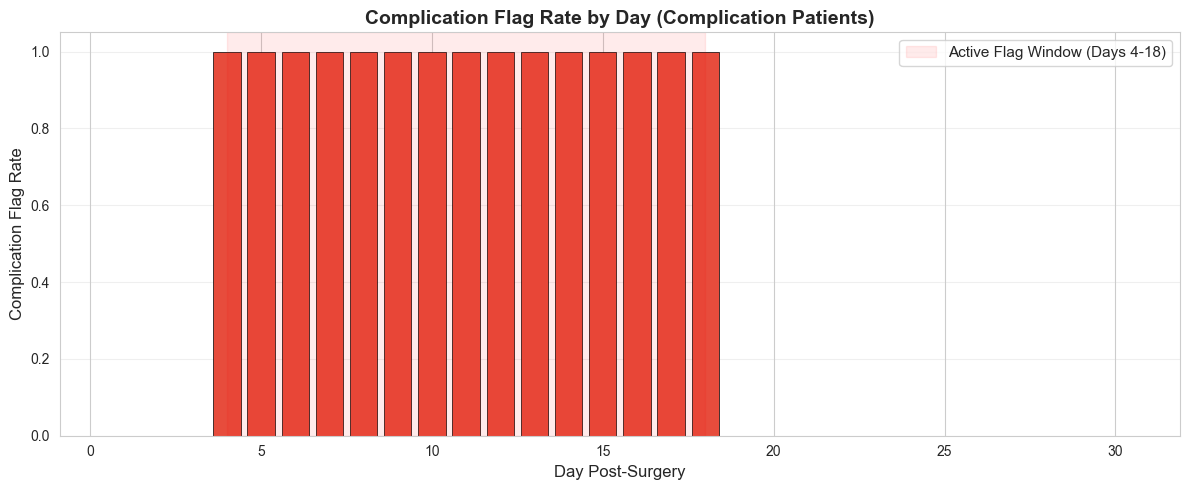

In [12]:
# Complication flag rate by day (complication patients only)
comp_df = df[df['outcome'] == 'complication']
flag_rate = comp_df.groupby('day')['complication_flag'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#e74c3c' if rate > 0 else '#95a5a6' for rate in flag_rate.values]
ax.bar(flag_rate.index, flag_rate.values, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_title("Complication Flag Rate by Day (Complication Patients)", fontsize=14, fontweight='bold')
ax.set_xlabel("Day Post-Surgery", fontsize=12)
ax.set_ylabel("Complication Flag Rate", fontsize=12)
ax.axvspan(4, 18, alpha=0.08, color='red', label='Active Flag Window (Days 4-18)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 12. Feature Distributions by Outcome (KDE)

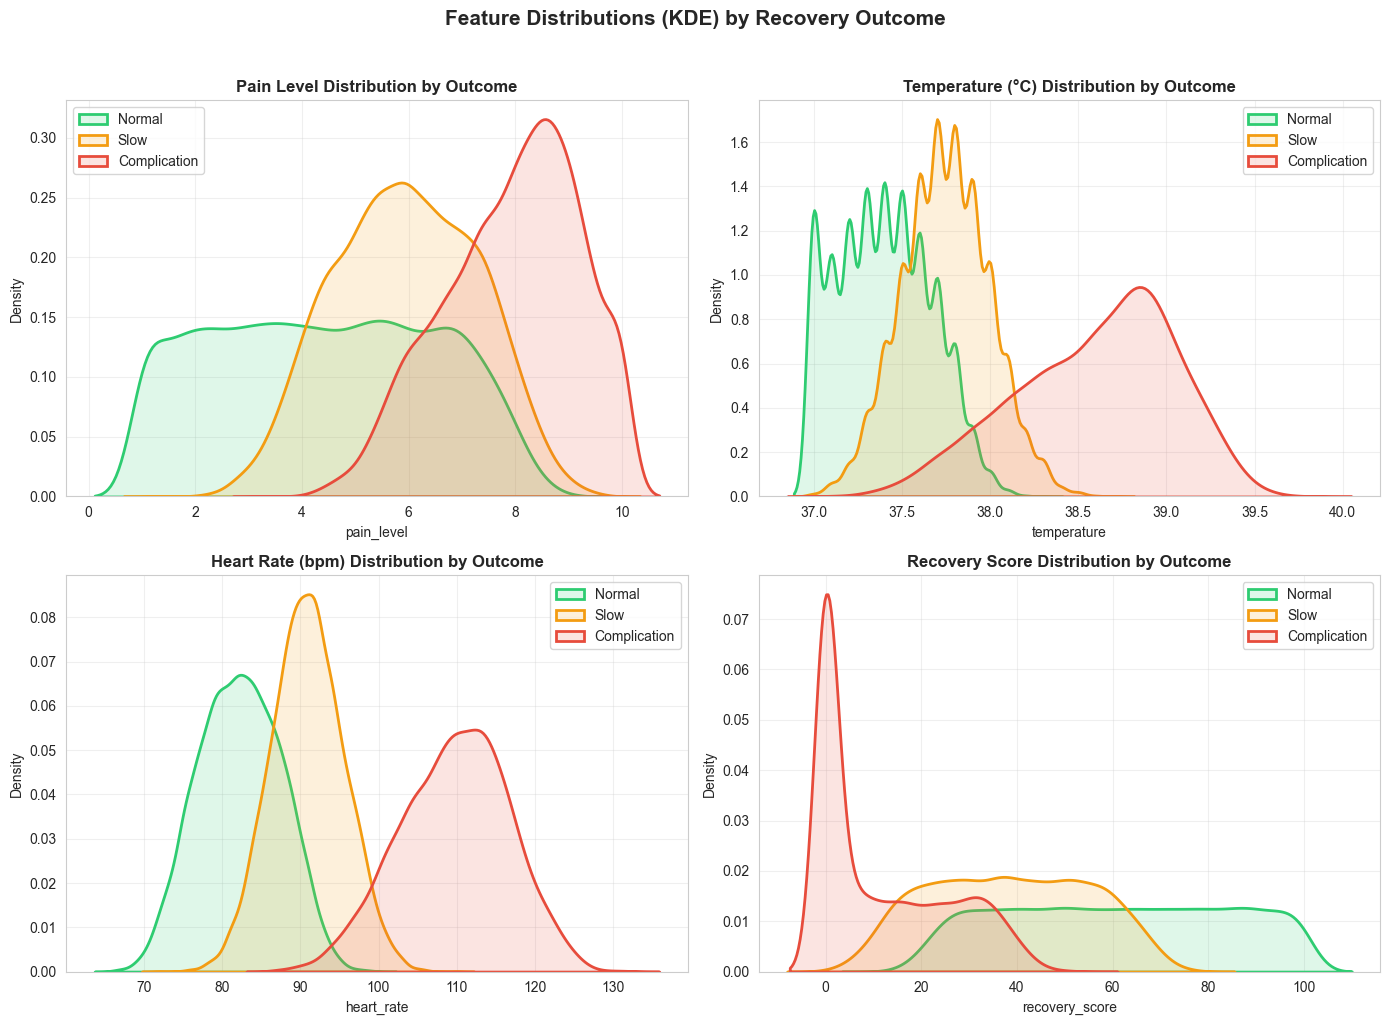

In [13]:
# KDE plots for key vitals by outcome
kde_features = ['pain_level', 'temperature', 'heart_rate', 'recovery_score']
kde_titles = ['Pain Level', 'Temperature (°C)', 'Heart Rate (bpm)', 'Recovery Score']
colors_map = {'normal': '#2ecc71', 'slow': '#f39c12', 'complication': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (feat, title) in enumerate(zip(kde_features, kde_titles)):
    ax = axes[idx]
    for outcome in ['normal', 'slow', 'complication']:
        subset = df[df['outcome'] == outcome]
        sns.kdeplot(subset[feat], ax=ax, label=outcome.capitalize(),
                    color=colors_map[outcome], linewidth=2, fill=True, alpha=0.15)
    ax.set_title(f"{title} Distribution by Outcome", fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Feature Distributions (KDE) by Recovery Outcome", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 13. LSTM Model Training
Train a hybrid dual-head LSTM model that combines temporal vital sign patterns with static patient features to predict:
1. **Recovery score** for the next 3 days (regression)
2. **Complication risk** (binary classification)

In [14]:
# LSTM Training — Configuration & Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, mean_absolute_error, confusion_matrix
import joblib

# Config
SEQUENCE_LENGTH = 7       # 7-day lookback
FORECAST_DAYS = 3         # Predict 3 days ahead
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

VITALS_FEATURES = ["pain_level", "temperature", "heart_rate", "bp_systolic",
                    "mobility_score", "wound_status", "sleep_hours"]
STATIC_FEATURES = ["age", "gender", "bmi", "diabetes", "hypertension", "smoking", "surgery_type_encoded"]

MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Model save directory: {MODEL_DIR}")

Using device: cpu
Model save directory: ..\models


### 13.1 Dataset Class & Model Architecture

In [15]:
# Dataset class
class RecoveryDataset(Dataset):
    def __init__(self, sequences, static_feats, targets_recovery, targets_complication):
        self.sequences = torch.FloatTensor(sequences)
        self.static_feats = torch.FloatTensor(static_feats)
        self.targets_recovery = torch.FloatTensor(targets_recovery)
        self.targets_complication = torch.FloatTensor(targets_complication)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (self.sequences[idx], self.static_feats[idx],
                self.targets_recovery[idx], self.targets_complication[idx])


# Hybrid LSTM Model
class RecoveryLSTM(nn.Module):
    def __init__(self, num_vitals, num_static, hidden_size, num_layers, forecast_days, dropout):
        super(RecoveryLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=num_vitals, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

        self.static_encoder = nn.Sequential(
            nn.Linear(num_static, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU())

        combined_size = hidden_size + 32

        self.recovery_head = nn.Sequential(
            nn.Linear(combined_size, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, forecast_days))

        self.complication_head = nn.Sequential(
            nn.Linear(combined_size, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1), nn.Sigmoid())

    def forward(self, vitals_seq, static_feats):
        lstm_out, (h_n, _) = self.lstm(vitals_seq)
        temporal_features = h_n[-1]
        static_encoded = self.static_encoder(static_feats)
        combined = torch.cat([temporal_features, static_encoded], dim=1)
        recovery_pred = self.recovery_head(combined)
        complication_pred = self.complication_head(combined).squeeze(-1)
        return recovery_pred, complication_pred

print("Dataset class and RecoveryLSTM model defined.")
print(f"Architecture: LSTM({HIDDEN_SIZE} units, {NUM_LAYERS} layers) + Static Encoder(7→64→32) + Dual Heads")

Dataset class and RecoveryLSTM model defined.
Architecture: LSTM(128 units, 2 layers) + Static Encoder(7→64→32) + Dual Heads


### 13.2 Data Preparation — Sliding Windows

In [16]:
# Reload fresh data (unscaled)
df_raw = pd.read_csv(os.path.join("..", "data", "synthetic_recovery_data.csv"))

# Encode surgery type
le = LabelEncoder()
df_raw["surgery_type_encoded"] = le.fit_transform(df_raw["surgery_type"])

# Scale vitals
vitals_scaler = StandardScaler()
df_raw[VITALS_FEATURES] = vitals_scaler.fit_transform(df_raw[VITALS_FEATURES])

# Scale static features
static_scaler = StandardScaler()
static_df = df_raw.groupby("patient_id")[STATIC_FEATURES].first()
static_scaler.fit(static_df)

# Create sliding window sequences
sequences, static_feats_list, targets_recovery, targets_complication = [], [], [], []
patient_ids = df_raw["patient_id"].unique()
print(f"Processing {len(patient_ids)} patients...")

for pid in patient_ids:
    patient_data = df_raw[df_raw["patient_id"] == pid].sort_values("day")
    vitals = patient_data[VITALS_FEATURES].values
    recovery_scores = patient_data["recovery_score"].values
    complication_flags = patient_data["complication_flag"].values
    static = patient_data[STATIC_FEATURES].iloc[0].values
    static_scaled = static_scaler.transform(static.reshape(1, -1))[0]

    for i in range(len(vitals) - SEQUENCE_LENGTH - FORECAST_DAYS + 1):
        seq = vitals[i: i + SEQUENCE_LENGTH]
        future_recovery = recovery_scores[i + SEQUENCE_LENGTH: i + SEQUENCE_LENGTH + FORECAST_DAYS]
        future_complication = max(complication_flags[i + SEQUENCE_LENGTH: i + SEQUENCE_LENGTH + FORECAST_DAYS])
        sequences.append(seq)
        static_feats_list.append(static_scaled)
        targets_recovery.append(future_recovery)
        targets_complication.append(future_complication)

sequences = np.array(sequences)
static_feats_arr = np.array(static_feats_list)
targets_recovery = np.array(targets_recovery)
targets_complication = np.array(targets_complication)

print(f"Total samples: {len(sequences)}")
print(f"Complication rate: {targets_complication.mean():.2%}")
print(f"Sequence shape: {sequences.shape}")
print(f"Static features shape: {static_feats_arr.shape}")

# Train/test split
indices = np.arange(len(sequences))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=targets_complication)

train_dataset = RecoveryDataset(sequences[train_idx], static_feats_arr[train_idx],
                                targets_recovery[train_idx], targets_complication[train_idx])
test_dataset = RecoveryDataset(sequences[test_idx], static_feats_arr[test_idx],
                               targets_recovery[test_idx], targets_complication[test_idx])

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

# Save scalers and encoder
joblib.dump(vitals_scaler, os.path.join(MODEL_DIR, "recovery_vitals_scaler.pkl"))
joblib.dump(static_scaler, os.path.join(MODEL_DIR, "recovery_static_scaler.pkl"))
joblib.dump(le, os.path.join(MODEL_DIR, "recovery_surgery_encoder.pkl"))
print("Scalers and encoder saved.")

Processing 1000 patients...
Total samples: 21000
Complication rate: 7.91%
Sequence shape: (21000, 7, 7)
Static features shape: (21000, 7)

Train samples: 16800
Test samples:  4200
Scalers and encoder saved.


### 13.3 Train the LSTM Model

In [17]:
# Training loop
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = RecoveryLSTM(
    num_vitals=len(VITALS_FEATURES), num_static=len(STATIC_FEATURES),
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    forecast_days=FORECAST_DAYS, dropout=DROPOUT
).to(DEVICE)

recovery_loss_fn = nn.MSELoss()
complication_loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training on {DEVICE}...\n")

# Track history
history = {'train_loss': [], 'val_loss': [], 'comp_acc': []}
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss_total = 0
    for vitals_seq, static, target_rec, target_comp in train_loader:
        vitals_seq, static = vitals_seq.to(DEVICE), static.to(DEVICE)
        target_rec, target_comp = target_rec.to(DEVICE), target_comp.to(DEVICE)

        optimizer.zero_grad()
        rec_pred, comp_pred = model(vitals_seq, static)
        loss = recovery_loss_fn(rec_pred, target_rec) + 2.0 * complication_loss_fn(comp_pred, target_comp)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss_total += loss.item()

    avg_train_loss = train_loss_total / len(train_loader)

    # Validate
    model.eval()
    val_loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        for vitals_seq, static, target_rec, target_comp in test_loader:
            vitals_seq, static = vitals_seq.to(DEVICE), static.to(DEVICE)
            target_rec, target_comp = target_rec.to(DEVICE), target_comp.to(DEVICE)
            rec_pred, comp_pred = model(vitals_seq, static)
            loss = recovery_loss_fn(rec_pred, target_rec) + 2.0 * complication_loss_fn(comp_pred, target_comp)
            val_loss_total += loss.item()
            predicted = (comp_pred > 0.5).float()
            correct += (predicted == target_comp).sum().item()
            total += target_comp.size(0)

    avg_val_loss = val_loss_total / len(test_loader)
    comp_acc = correct / total
    scheduler.step(avg_val_loss)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['comp_acc'].append(comp_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Complication Acc: {comp_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "config": {
                "num_vitals": len(VITALS_FEATURES), "num_static": len(STATIC_FEATURES),
                "hidden_size": HIDDEN_SIZE, "num_layers": NUM_LAYERS,
                "forecast_days": FORECAST_DAYS, "dropout": DROPOUT,
                "sequence_length": SEQUENCE_LENGTH,
                "vitals_features": VITALS_FEATURES, "static_features": STATIC_FEATURES,
            },
            "epoch": best_epoch, "val_loss": best_val_loss, "complication_acc": comp_acc,
        }
        torch.save(checkpoint, os.path.join(MODEL_DIR, "recovery_lstm_model.pth"))

print(f"\nBest model saved at epoch {best_epoch} with val loss: {best_val_loss:.4f}")

Model parameters: 225,700
Training on cpu...

Epoch  1/30 | Train Loss: 822.0967 | Val Loss: 22.2253 | Complication Acc: 0.9919
Epoch  5/30 | Train Loss: 59.0055 | Val Loss: 18.3386 | Complication Acc: 0.9931
Epoch 10/30 | Train Loss: 53.4435 | Val Loss: 18.5809 | Complication Acc: 0.9964
Epoch 15/30 | Train Loss: 52.4102 | Val Loss: 20.3159 | Complication Acc: 0.9940
Epoch 20/30 | Train Loss: 50.9246 | Val Loss: 18.4218 | Complication Acc: 0.9969
Epoch 25/30 | Train Loss: 48.4338 | Val Loss: 16.0230 | Complication Acc: 0.9971
Epoch 30/30 | Train Loss: 45.3104 | Val Loss: 15.9216 | Complication Acc: 0.9983

Best model saved at epoch 24 with val loss: 15.4445


### 13.4 Training Curves

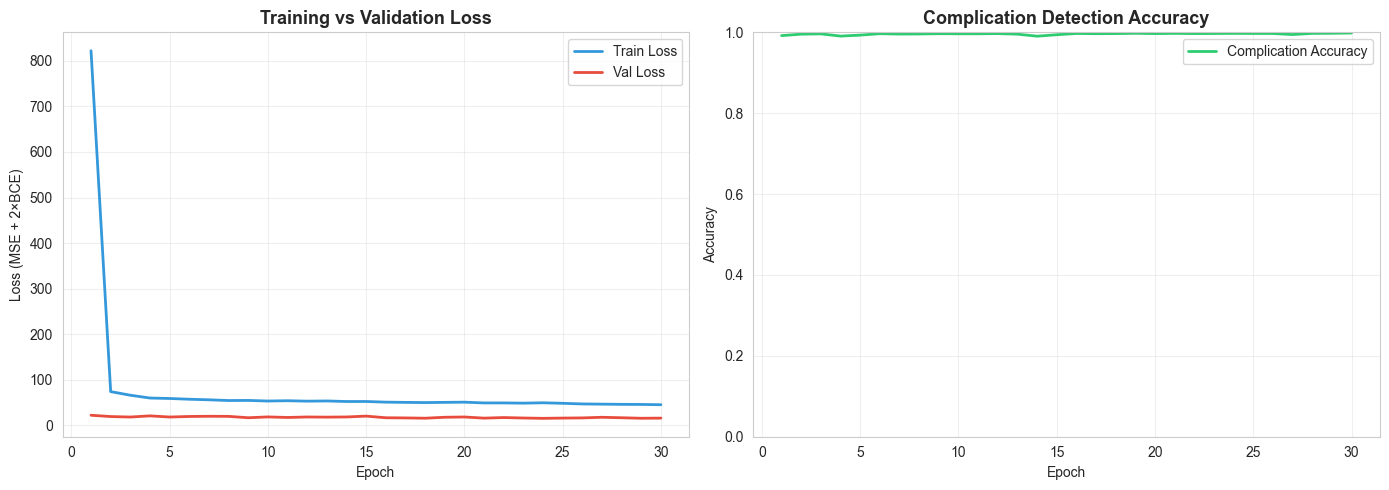

In [18]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE + 2×BCE)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Complication accuracy
axes[1].plot(epochs_range, history['comp_acc'], label='Complication Accuracy', color='#2ecc71', linewidth=2)
axes[1].set_title("Complication Detection Accuracy", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 14. Model Evaluation

In [19]:
# Final evaluation on test set
model.eval()
all_rec_true, all_rec_pred = [], []
all_comp_true, all_comp_pred = [], []

with torch.no_grad():
    for vitals_seq, static, target_rec, target_comp in test_loader:
        vitals_seq, static = vitals_seq.to(DEVICE), static.to(DEVICE)
        rec_pred, comp_pred = model(vitals_seq, static)
        all_rec_true.append(target_rec.numpy())
        all_rec_pred.append(rec_pred.cpu().numpy())
        all_comp_true.append(target_comp.numpy())
        all_comp_pred.append(comp_pred.cpu().numpy())

all_rec_true = np.concatenate(all_rec_true)
all_rec_pred = np.concatenate(all_rec_pred)
all_comp_true = np.concatenate(all_comp_true)
all_comp_pred = np.concatenate(all_comp_pred)
all_comp_binary = (all_comp_pred > 0.5).astype(float)

# Recovery MAE
mae = mean_absolute_error(all_rec_true.flatten(), all_rec_pred.flatten())
print("=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)
print(f"\nRecovery Score MAE: {mae:.4f}")
print(f"\nComplication Detection Classification Report:")
print(classification_report(all_comp_true, all_comp_binary, target_names=["No Complication", "Complication"]))

FINAL EVALUATION ON TEST SET

Recovery Score MAE: 3.0717

Complication Detection Classification Report:
                 precision    recall  f1-score   support

No Complication       1.00      1.00      1.00      3868
   Complication       0.99      0.99      0.99       332

       accuracy                           1.00      4200
      macro avg       0.99      1.00      0.99      4200
   weighted avg       1.00      1.00      1.00      4200



### 14.1 Confusion Matrix

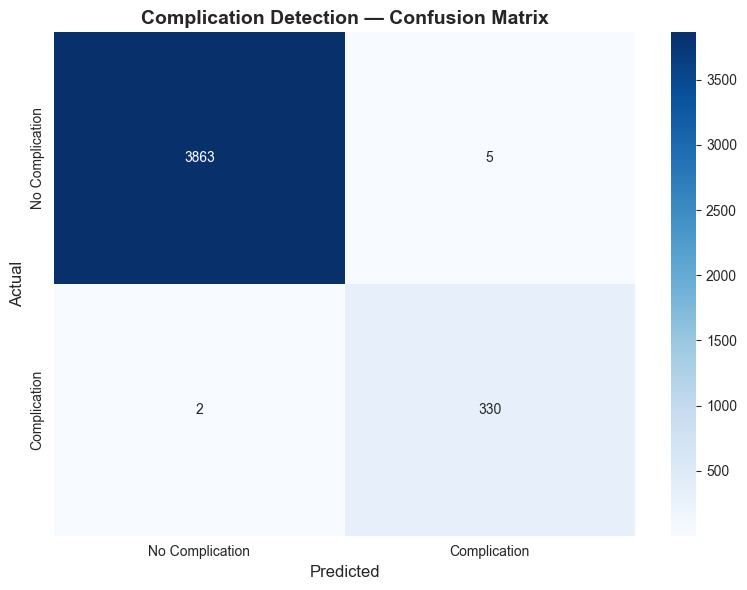

In [20]:
# Confusion matrix for complication detection
cm = confusion_matrix(all_comp_true, all_comp_binary)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=["No Complication", "Complication"],
            yticklabels=["No Complication", "Complication"])
ax.set_title("Complication Detection — Confusion Matrix", fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

### 14.2 Recovery Prediction vs Actual

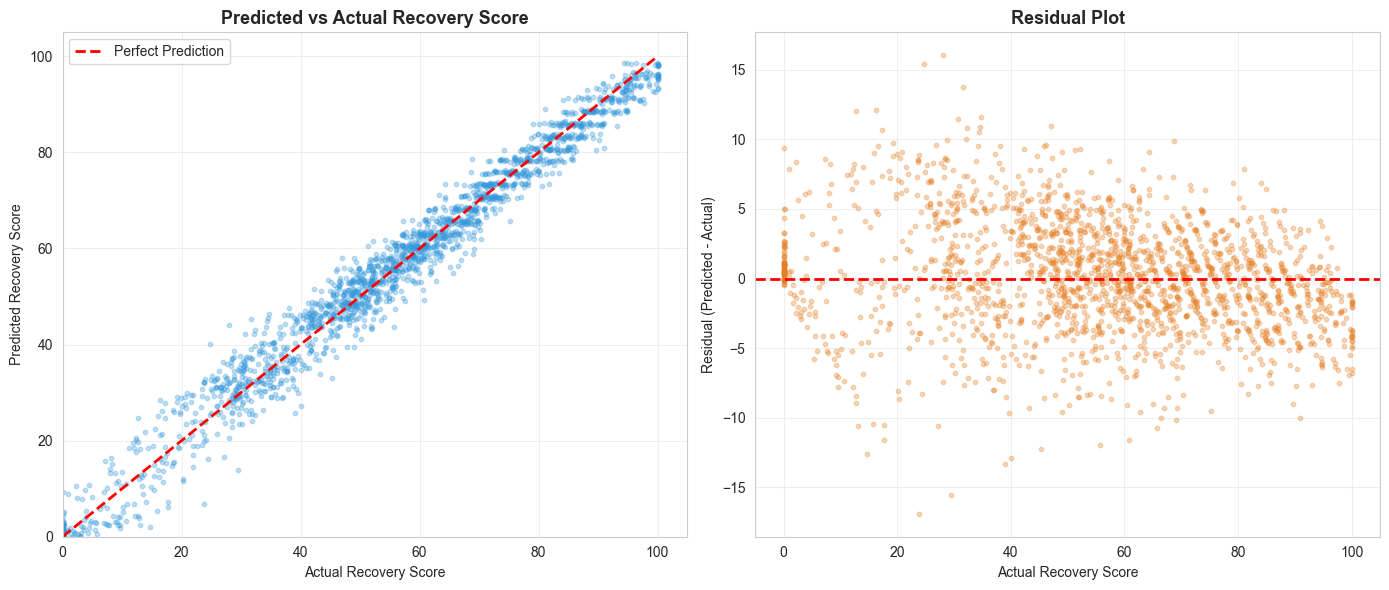

Mean Residual: 0.1284
Std Residual:  3.9594


In [21]:
# Predicted vs actual recovery scores
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sample predictions (flatten all 3-day forecasts)
true_flat = all_rec_true.flatten()
pred_flat = all_rec_pred.flatten()
sample_idx = np.random.choice(len(true_flat), size=min(2000, len(true_flat)), replace=False)

# Scatter plot
axes[0].scatter(true_flat[sample_idx], pred_flat[sample_idx], alpha=0.3, s=10, color='#3498db')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title("Predicted vs Actual Recovery Score", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Recovery Score")
axes[0].set_ylabel("Predicted Recovery Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 105)
axes[0].set_ylim(0, 105)

# Residual plot
residuals = pred_flat[sample_idx] - true_flat[sample_idx]
axes[1].scatter(true_flat[sample_idx], residuals, alpha=0.3, s=10, color='#e67e22')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residual Plot", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual Recovery Score")
axes[1].set_ylabel("Residual (Predicted - Actual)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual:  {residuals.std():.4f}")

## 15. Summary

**Dataset:**
- 1,000 patients × 30 days = 30,000 records
- 3 recovery outcomes: Normal (54%), Slow (31%), Complication (15%)
- 4 surgery types: Cardiac, Orthopedic, Abdominal, Neurological

**Key EDA Findings:**
- Complication patients show clear vital sign spikes (temperature, heart rate, pain) during days 5-15
- Normal recovery patients reach ~90+ recovery score by day 30; complication patients plateau around 40-60
- Higher age, BMI, and comorbidities correlate with increased complication risk
- Wound healing is significantly slower in complication patients

**LSTM Model:**
- Architecture: 2-layer LSTM (128 units) + Static Encoder + Dual Output Heads
- Recovery Head: 3-day forecast (MSE loss)
- Complication Head: Binary risk classification (BCE loss × 2.0 weight)
- Trained for 30 epochs with Adam optimizer + ReduceLROnPlateau